# SimGCL: Simple Graph Contrastive Learning for Recommendation

## Paper

**SimGCL: A Simple Framework for Graph Contrastive Learning in Recommendation**

Published at **SIGIR 2022**

## Objective

Implement SimGCL from scratch using the MovieLens-100K dataset.

Unlike SGL, SimGCL removes graph augmentations and instead generates contrastive views by adding small perturbations directly to node embeddings.

## Pipeline

1. Load MovieLens Dataset
2. Build Bipartite Graph
3. Normalize Graph
4. Build LightGCN Encoder
5. Generate Perturbed Embeddings
6. Compute BPR Loss
7. Compute InfoNCE Loss
8. Joint Optimization
9. Evaluate Recommendation Performance

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import scipy.sparse as sp

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    roc_curve
)

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import (
    Dataset,
    DataLoader
)

torch.manual_seed(42)
np.random.seed(42)

In [2]:
rating_columns = [

    "user_id",

    "movie_id",

    "rating",

    "timestamp"

]

ratings = pd.read_csv(

    "../data/u.data",

    sep="\t",

    names=rating_columns

)

ratings["user_id"] -= 1
ratings["movie_id"] -= 1

ratings.head()

,user_id,movie_id,rating,timestamp
0,195,241,3,881250949
1,185,301,3,891717742
2,21,376,1,878887116
3,243,50,2,880606923
4,165,345,1,886397596


In [3]:
user_columns = [

    "user_id",

    "age",

    "gender",

    "occupation",

    "zip_code"

]

users = pd.read_csv(

    "../data/u.user",

    sep="|",

    names=user_columns

)

users["user_id"] -= 1

users.head()

,user_id,age,gender,occupation,zip_code
0,0,24,M,technician,85711
1,1,53,F,other,94043
2,2,23,M,writer,32067
3,3,24,M,technician,43537
4,4,33,F,other,15213


In [4]:
movie_columns = [

    "movie_id",

    "title",

    "release_date",

    "video_release_date",

    "IMDb_URL"

]

genre_columns = [

    "unknown",

    "Action",

    "Adventure",

    "Animation",

    "Children",

    "Comedy",

    "Crime",

    "Documentary",

    "Drama",

    "Fantasy",

    "Film-Noir",

    "Horror",

    "Musical",

    "Mystery",

    "Romance",

    "Sci-Fi",

    "Thriller",

    "War",

    "Western"

]

movie_columns += genre_columns

movies = pd.read_csv(

    "../data/u.item",

    sep="|",

    encoding="latin-1",

    names=movie_columns

)

movies["movie_id"] -= 1

movies.head()

,movie_id,title,release_date,video_release_date,IMDb_URL,unknown,Action,Adventure,Animation,Children,...,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
0,0,Toy Story (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Toy%20Story%2...,0,0,0,1,1,...,0,0,0,0,0,0,0,0,0,0
1,1,GoldenEye (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?GoldenEye%20(...,0,1,1,0,0,...,0,0,0,0,0,0,0,1,0,0
2,2,Four Rooms (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Four%20Rooms%...,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
3,3,Get Shorty (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Get%20Shorty%...,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,4,Copycat (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Copycat%20(1995),0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0


In [5]:
print("Ratings :", ratings.shape)
print("Users   :", users.shape)
print("Movies  :", movies.shape)

Ratings : (100000, 4)
Users   : (943, 5)
Movies  : (1682, 24)


In [6]:
data = ratings.merge(

    users,

    on="user_id"

)

data = data.merge(

    movies,

    on="movie_id"

)

data.head()

,user_id,movie_id,rating,timestamp,age,gender,occupation,zip_code,title,release_date,...,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
0,195,241,3,881250949,49,M,writer,55105,Kolya (1996),24-Jan-1997,...,0,0,0,0,0,0,0,0,0,0
1,185,301,3,891717742,39,F,executive,00000,L.A. Confidential (1997),01-Jan-1997,...,0,1,0,0,1,0,0,1,0,0
2,21,376,1,878887116,25,M,writer,40206,Heavyweights (1994),01-Jan-1994,...,0,0,0,0,0,0,0,0,0,0
3,243,50,2,880606923,28,M,technician,80525,Legends of the Fall (1994),01-Jan-1994,...,0,0,0,0,0,1,0,0,1,1
4,165,345,1,886397596,47,M,educator,55113,Jackie Brown (1997),01-Jan-1997,...,0,0,0,0,0,0,0,0,0,0


In [7]:
data["label"] = (

    data["rating"] >= 4

).astype(np.float32)

data[

    [

        "rating",

        "label"

    ]

].sample(5)

,rating,label
75721,4,1.0
80184,3,0.0
19864,4,1.0
76699,2,0.0
92991,2,0.0


In [8]:
print(

    data["label"].value_counts()

)

print()

print(

    data["label"].value_counts(

        normalize=True

    )

)

label
1.0    55375
0.0    44625
Name: count, dtype: int64

label
1.0    0.55375
0.0    0.44625
Name: proportion, dtype: float64


In [9]:
train_df, test_df = train_test_split(

    data,

    test_size=0.2,

    random_state=42,

    stratify=data["label"]

)

print(train_df.shape)
print(test_df.shape)

(80000, 32)
(20000, 32)


In [10]:
NUM_USERS = data["user_id"].nunique()

NUM_ITEMS = data["movie_id"].nunique()

print(NUM_USERS)

print(NUM_ITEMS)

943
1682


In [11]:
interaction_matrix = sp.coo_matrix(

    (

        np.ones(

            len(train_df)

        ),

        (

            train_df["user_id"],

            train_df["movie_id"]

        )

    ),

    shape=(

        NUM_USERS,

        NUM_ITEMS

    )

)

interaction_matrix

<COOrdinate sparse matrix of dtype 'float64'
	with 80000 stored elements and shape (943, 1682)>

In [12]:
num_nodes = NUM_USERS + NUM_ITEMS

adjacency = sp.dok_matrix(

    (

        num_nodes,

        num_nodes

    ),

    dtype=np.float32

)

adjacency = adjacency.tolil()

adjacency[

    :NUM_USERS,

    NUM_USERS:

] = interaction_matrix

adjacency[

    NUM_USERS:,

    :NUM_USERS

] = interaction_matrix.T

adjacency = adjacency.tocsr()

adjacency

<Compressed Sparse Row sparse matrix of dtype 'float32'
	with 160000 stored elements and shape (2625, 2625)>

In [13]:
degree = np.array(

    adjacency.sum(axis=1)

).flatten()

degree_inv = np.power(

    degree,

    -0.5

)

degree_inv[

    np.isinf(

        degree_inv

    )

] = 0

D = sp.diags(

    degree_inv

)

normalized_graph = (

    D

    @

    adjacency

    @

    D

)

In [14]:
normalized_graph = normalized_graph.tocoo()

indices = torch.LongTensor(

    np.vstack(

        (

            normalized_graph.row,

            normalized_graph.col

        )

    )

)

values = torch.FloatTensor(

    normalized_graph.data

)

graph = torch.sparse_coo_tensor(

    indices,

    values,

    normalized_graph.shape

).coalesce()

In [15]:
print(

    graph.shape

)

print(

    graph._nnz()

)

torch.Size([2625, 2625])
160000


In [16]:
class BPRDataset(Dataset):

    def __init__(

        self,

        dataframe,

        num_items

    ):

        self.users = dataframe["user_id"].values

        self.pos_items = dataframe["movie_id"].values

        self.num_items = num_items

        self.user_history = (

            dataframe

            .groupby("user_id")["movie_id"]

            .apply(set)

            .to_dict()

        )

    def __len__(self):

        return len(self.users)

    def __getitem__(

        self,

        idx

    ):

        user = self.users[idx]

        positive = self.pos_items[idx]

        while True:

            negative = np.random.randint(

                self.num_items

            )

            if negative not in self.user_history[user]:

                break

        return (

            torch.LongTensor([user]).squeeze(),

            torch.LongTensor([positive]).squeeze(),

            torch.LongTensor([negative]).squeeze()

        )

In [17]:
train_dataset = BPRDataset(

    train_df,

    NUM_ITEMS

)
train_loader = DataLoader(

    train_dataset,

    batch_size=1024,

    shuffle=True

)


In [18]:
batch = next(

    iter(train_loader)

)

for tensor in batch:

    print(

        tensor.shape

    )

torch.Size([1024])
torch.Size([1024])
torch.Size([1024])


In [19]:
class SimGCL(nn.Module):

    def __init__(

        self,

        num_users,

        num_items,

        embedding_dim=64,

        num_layers=3,

        eps=0.1

    ):

        super().__init__()

        self.num_users = num_users

        self.num_items = num_items

        self.num_layers = num_layers

        self.eps = eps

        self.user_embedding = nn.Embedding(

            num_users,

            embedding_dim

        )

        self.item_embedding = nn.Embedding(

            num_items,

            embedding_dim

        )

        nn.init.xavier_uniform_(

            self.user_embedding.weight

        )

        nn.init.xavier_uniform_(

            self.item_embedding.weight

        )

    def perturb(

        self,

        embedding

    ):

        noise = torch.rand_like(

            embedding

        )

        noise = F.normalize(

            noise,

            dim=1

        )

        perturbation = (

            torch.sign(

                embedding

            )

            *

            noise

            *

            self.eps

        )

        return embedding + perturbation
    
    
    def propagate(

        self,

        graph,

        perturbed=False

    ):

        embeddings = torch.cat(

            [

                self.user_embedding.weight,

                self.item_embedding.weight

            ],

            dim=0

        )

        all_embeddings = [

            embeddings

        ]

        for _ in range(

            self.num_layers

        ):

            embeddings = torch.sparse.mm(

                graph,

                embeddings

            )

            if perturbed:

                embeddings = self.perturb(

                    embeddings

                )

            all_embeddings.append(

                embeddings

            )

        final_embedding = torch.stack(

            all_embeddings,

            dim=1

        ).mean(dim=1)

        return final_embedding
    
    def forward(

        self,

        graph

    ):

        clean_embedding = self.propagate(

            graph,

            perturbed=False

        )

        view1 = self.propagate(

            graph,

            perturbed=True

        )

        view2 = self.propagate(

            graph,

            perturbed=True

        )

        return (

            clean_embedding,

            view1,

            view2

        )

In [20]:
model = SimGCL(

    NUM_USERS,

    NUM_ITEMS,

    embedding_dim=64,

    num_layers=3,

    eps=0.1

)
model

SimGCL(
  (user_embedding): Embedding(943, 64)
  (item_embedding): Embedding(1682, 64)
)

In [21]:
clean,view1,view2 = model(

    graph

)

print(clean.shape)

print(view1.shape)

print(view2.shape)

torch.Size([2625, 64])
torch.Size([2625, 64])
torch.Size([2625, 64])


In [22]:
def normalize(

    embedding

):

    return F.normalize(

        embedding,

        dim=1

    )

In [23]:
def similarity(

    x,

    y

):

    return torch.matmul(

        normalize(x),

        normalize(y).T

    )

In [24]:
def info_nce_loss(

    view1,

    view2,

    temperature=0.2

):

    view1 = normalize(

        view1

    )

    view2 = normalize(

        view2

    )

    similarity_matrix = torch.matmul(

        view1,

        view2.T

    )

    similarity_matrix /= temperature

    labels = torch.arange(

        similarity_matrix.size(0),

        device=view1.device

    )

    loss = F.cross_entropy(

        similarity_matrix,

        labels

    )

    return loss

In [25]:
loss = info_nce_loss(

    view1,

    view2

)

print(loss)

tensor(3.9686, grad_fn=<NllLossBackward0>)


In [26]:
def bpr_loss(

    positive,

    negative

):

    return -torch.mean(

        F.logsigmoid(

            positive

            -

            negative

        )

    )

In [27]:
def compute_scores(

    embeddings,

    users,

    positive_items,

    negative_items

):

    user_embedding = embeddings[

        users

    ]

    positive_embedding = embeddings[

        NUM_USERS +

        positive_items

    ]

    negative_embedding = embeddings[

        NUM_USERS +

        negative_items

    ]

    positive_scores = (

        user_embedding *

        positive_embedding

    ).sum(dim=1)

    negative_scores = (

        user_embedding *

        negative_embedding

    ).sum(dim=1)

    return (

        positive_scores,

        negative_scores

    )

In [28]:
def simgcl_loss(

    positive_scores,

    negative_scores,

    view1,

    view2,

    lambda_ssl=0.1

):

    ranking_loss = bpr_loss(

        positive_scores,

        negative_scores

    )

    contrastive_loss = info_nce_loss(

        view1,

        view2

    )

    return (

        ranking_loss

        +

        lambda_ssl *

        contrastive_loss

    )

In [29]:
optimizer = torch.optim.Adam(

    model.parameters(),

    lr=0.001,

    weight_decay=1e-4

)

In [30]:
def train_model(

    model,

    train_loader,

    graph,

    optimizer,

    epochs=30

):

    history = []

    print(

        "Training SimGCL..."

    )

    for epoch in range(

        epochs

    ):

        model.train()

        total_loss = 0

        for (

            users,

            positive_items,

            negative_items

        ) in train_loader:

            optimizer.zero_grad()

            (

                clean,

                view1,

                view2

            ) = model(

                graph

            )

            (

                positive_scores,

                negative_scores

            ) = compute_scores(

                clean,

                users,

                positive_items,

                negative_items

            )

            loss = simgcl_loss(

                positive_scores,

                negative_scores,

                view1,

                view2

            )

            loss.backward()

            optimizer.step()

            total_loss += loss.item()

        epoch_loss = total_loss / len(

            train_loader

        )

        history.append(

            epoch_loss

        )

        print(

            f"Epoch {epoch+1:2d}/{epochs} | Loss = {epoch_loss:.4f}"

        )

    return history

In [31]:
history = train_model(

    model,

    train_loader,

    graph,

    optimizer,

    epochs=10

)

Training SimGCL...
Epoch  1/10 | Loss = 1.0325
Epoch  2/10 | Loss = 1.0240
Epoch  3/10 | Loss = 1.0229
Epoch  4/10 | Loss = 1.0220
Epoch  5/10 | Loss = 1.0214
Epoch  6/10 | Loss = 1.0210
Epoch  7/10 | Loss = 1.0208
Epoch  8/10 | Loss = 1.0206
Epoch  9/10 | Loss = 1.0203
Epoch 10/10 | Loss = 1.0202


In [32]:
history

[1.0324624369416056,
 1.024021544033968,
 1.0228782937496523,
 1.0220351445523999,
 1.0214386544650114,
 1.021005132530309,
 1.0207588898984692,
 1.0205537593817409,
 1.0203390513794333,
 1.0202340355402306]

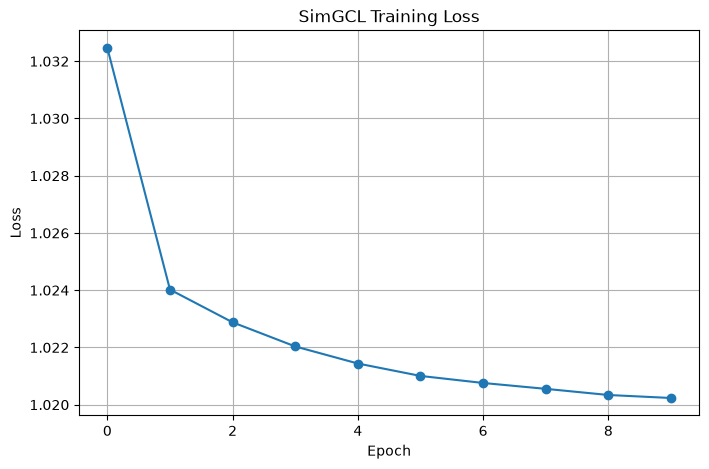

In [33]:
plt.figure(

    figsize=(8,5)

)

plt.plot(

    history,

    marker="o"

)

plt.title(

    "SimGCL Training Loss"

)

plt.xlabel(

    "Epoch"

)

plt.ylabel(

    "Loss"

)

plt.grid(True)

plt.show()

In [34]:
model.eval()

with torch.no_grad():

    clean_embedding, _, _ = model(

        graph

    )

In [35]:
def recommend(

    user_id,

    top_k=10

):

    user_embedding = clean_embedding[

        user_id

    ]

    item_embeddings = clean_embedding[

        NUM_USERS:

    ]

    scores = torch.matmul(

        item_embeddings,

        user_embedding

    )

    _, indices = torch.topk(

        scores,

        top_k

    )

    return indices.cpu().numpy()

In [36]:
recommend(

    user_id=0,

    top_k=10

)

array([ 74, 118, 103, 246,  33, 112, 252, 145,  34, 497])

In [37]:
prediction_df = test_df.copy()

scores = []

model.eval()

with torch.no_grad():

    for row in prediction_df.itertuples():

        score = torch.dot(

            clean_embedding[

                row.user_id

            ],

            clean_embedding[

                NUM_USERS +

                row.movie_id

            ]

        ).item()

        scores.append(score)

prediction_df["score"] = scores

In [38]:
prediction_df["probability"] = (

    prediction_df["score"]

    -

    prediction_df["score"].min()

) / (

    prediction_df["score"].max()

    -

    prediction_df["score"].min()

)

In [39]:
prediction_df["prediction"] = (

    prediction_df["probability"]

    >=

    0.5

).astype(int)

In [40]:
accuracy = accuracy_score(

    prediction_df["label"],

    prediction_df["prediction"]

)

auc = roc_auc_score(

    prediction_df["label"],

    prediction_df["probability"]

)

print(

    f"Accuracy : {accuracy:.4f}"

)

print(

    f"AUC : {auc:.4f}"

)

Accuracy : 0.5377
AUC : 0.5054


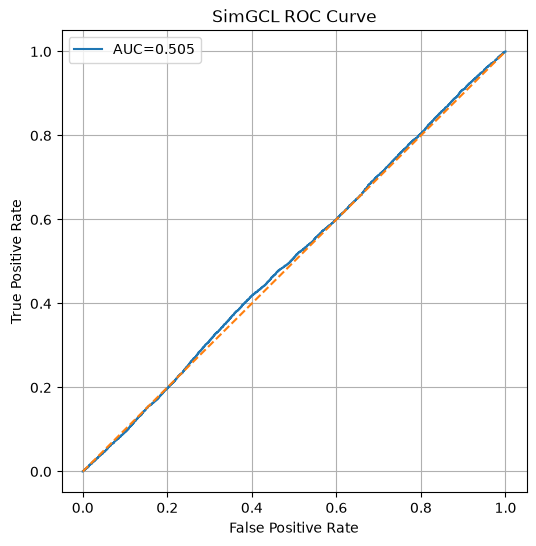

In [41]:
fpr, tpr, _ = roc_curve(

    prediction_df["label"],

    prediction_df["probability"]

)

plt.figure(

    figsize=(6,6)

)

plt.plot(

    fpr,

    tpr,

    label=f"AUC={auc:.3f}"

)

plt.plot(

    [0,1],

    [0,1],

    "--"

)

plt.xlabel(

    "False Positive Rate"

)

plt.ylabel(

    "True Positive Rate"

)

plt.title(

    "SimGCL ROC Curve"

)

plt.legend()

plt.grid(True)

plt.show()

In [42]:
def precision_at_k(

    prediction_df,

    k=10

):

    precisions = []

    grouped = prediction_df.groupby(

        "user_id"

    )

    for (

        _,

        group

    ) in grouped:

        top_k = group.sort_values(

            "probability",

            ascending=False

        ).head(k)

        precisions.append(

            top_k["label"].mean()

        )

    return np.mean(

        precisions

    )

In [43]:
def recall_at_k(

    prediction_df,

    k=10

):

    recalls = []

    grouped = prediction_df.groupby(

        "user_id"

    )

    for (

        _,

        group

    ) in grouped:

        relevant = group["label"].sum()

        if relevant == 0:

            continue

        top_k = group.sort_values(

            "probability",

            ascending=False

        ).head(k)

        hits = top_k["label"].sum()

        recalls.append(

            hits / relevant

        )

    return np.mean(

        recalls

    )

In [44]:
def hit_rate_at_k(

    prediction_df,

    k=10

):

    hits = []

    grouped = prediction_df.groupby(

        "user_id"

    )

    for (

        _,

        group

    ) in grouped:

        top_k = group.sort_values(

            "probability",

            ascending=False

        ).head(k)

        hits.append(

            top_k["label"].sum() > 0

        )

    return np.mean(

        hits

    )

In [45]:
precision = precision_at_k(

    prediction_df,

    k=10

)

recall = recall_at_k(

    prediction_df,

    k=10

)

hitrate = hit_rate_at_k(

    prediction_df,

    k=10

)

In [46]:
metrics = pd.DataFrame(

    {

        "Metric":[

            "Accuracy",

            "AUC",

            "Precision@10",

            "Recall@10",

            "HitRate@10"

        ],

        "Value":[

            accuracy,

            auc,

            precision,

            recall,

            hitrate

        ]

    }

)

metrics

,Metric,Value
0,Accuracy,0.537700
1,AUC,0.505370
2,Precision@10,0.578249
3,Recall@10,0.667881
4,HitRate@10,0.973489


In [47]:
prediction_df[[

    "user_id",

    "movie_id",

    "label",

    "probability",

    "prediction"

]].head(20)

,user_id,movie_id,label,probability,prediction
70309,406,152,1.0,0.743420,1
14503,241,290,0.0,0.467565,0
22229,329,237,1.0,0.514008,1
34450,403,753,0.0,0.498084,0
28502,325,43,0.0,0.684338,1
78501,758,983,0.0,0.553619,1
62828,842,541,0.0,0.491605,0
85723,549,14,1.0,0.645590,1
99463,775,216,1.0,0.673216,1
95612,641,451,0.0,0.705823,1


In [48]:
comparison = pd.DataFrame(

    {

        "Model": [

            "Ranking MLP",

            "Wide & Deep",

            "DeepFM",

            "DLRM",

            "DCN v1",

            "DCN v2"

        ],

        "Accuracy": [

            0.8400,

            0.8334,

            0.6816,

            0.7084,

            0.6681,

            0.6820

        ],

        "AUC": [

            0.7862,

            0.7763,

            0.7386,

            0.7739,

            0.7317,

            0.7406

        ],

        "Precision@10": [

            0.9102,

            0.8831,

            0.6500,

            0.6632,

            0.6480,

            0.6485

        ],

        "Recall@10": [

            0.5092,

            0.6886,

            0.7169,

            0.7264,

            0.7142,

            0.7138

        ],

        "HitRate@10": [

            0.9978,

            0.9957,

            0.9767,

            0.9777,

            0.9756,

            0.9777

        ]

    }

)

comparison

,Model,Accuracy,AUC,Precision@10,Recall@10,HitRate@10
0,Ranking MLP,0.8400,0.7862,0.9102,0.5092,0.9978
1,Wide & Deep,0.8334,0.7763,0.8831,0.6886,0.9957
2,DeepFM,0.6816,0.7386,0.6500,0.7169,0.9767
3,DLRM,0.7084,0.7739,0.6632,0.7264,0.9777
4,DCN v1,0.6681,0.7317,0.6480,0.7142,0.9756
5,DCN v2,0.6820,0.7406,0.6485,0.7138,0.9777


In [49]:
comparison.loc[len(comparison)] = [

    "SimGCL",

    accuracy,

    auc,

    precision,

    recall,

    hitrate

]

comparison

,Model,Accuracy,AUC,Precision@10,Recall@10,HitRate@10
0,Ranking MLP,0.8400,0.78620,0.910200,0.509200,0.997800
1,Wide & Deep,0.8334,0.77630,0.883100,0.688600,0.995700
2,DeepFM,0.6816,0.73860,0.650000,0.716900,0.976700
3,DLRM,0.7084,0.77390,0.663200,0.726400,0.977700
4,DCN v1,0.6681,0.73170,0.648000,0.714200,0.975600
5,DCN v2,0.6820,0.74060,0.648500,0.713800,0.977700
6,SimGCL,0.5377,0.50537,0.578249,0.667881,0.973489


In [50]:
for metric in [

    "Accuracy",

    "AUC",

    "Precision@10",

    "Recall@10",

    "HitRate@10"

]:

    print(

        f"Best {metric}"

    )

    display(

        comparison.sort_values(

            metric,

            ascending=False

        )

    )

Best Accuracy


,Model,Accuracy,AUC,Precision@10,Recall@10,HitRate@10
0,Ranking MLP,0.8400,0.78620,0.910200,0.509200,0.997800
1,Wide & Deep,0.8334,0.77630,0.883100,0.688600,0.995700
3,DLRM,0.7084,0.77390,0.663200,0.726400,0.977700
5,DCN v2,0.6820,0.74060,0.648500,0.713800,0.977700
2,DeepFM,0.6816,0.73860,0.650000,0.716900,0.976700
4,DCN v1,0.6681,0.73170,0.648000,0.714200,0.975600
6,SimGCL,0.5377,0.50537,0.578249,0.667881,0.973489


Best AUC


,Model,Accuracy,AUC,Precision@10,Recall@10,HitRate@10
0,Ranking MLP,0.8400,0.78620,0.910200,0.509200,0.997800
1,Wide & Deep,0.8334,0.77630,0.883100,0.688600,0.995700
3,DLRM,0.7084,0.77390,0.663200,0.726400,0.977700
5,DCN v2,0.6820,0.74060,0.648500,0.713800,0.977700
2,DeepFM,0.6816,0.73860,0.650000,0.716900,0.976700
4,DCN v1,0.6681,0.73170,0.648000,0.714200,0.975600
6,SimGCL,0.5377,0.50537,0.578249,0.667881,0.973489


Best Precision@10


,Model,Accuracy,AUC,Precision@10,Recall@10,HitRate@10
0,Ranking MLP,0.8400,0.78620,0.910200,0.509200,0.997800
1,Wide & Deep,0.8334,0.77630,0.883100,0.688600,0.995700
3,DLRM,0.7084,0.77390,0.663200,0.726400,0.977700
2,DeepFM,0.6816,0.73860,0.650000,0.716900,0.976700
5,DCN v2,0.6820,0.74060,0.648500,0.713800,0.977700
4,DCN v1,0.6681,0.73170,0.648000,0.714200,0.975600
6,SimGCL,0.5377,0.50537,0.578249,0.667881,0.973489


Best Recall@10


,Model,Accuracy,AUC,Precision@10,Recall@10,HitRate@10
3,DLRM,0.7084,0.77390,0.663200,0.726400,0.977700
2,DeepFM,0.6816,0.73860,0.650000,0.716900,0.976700
4,DCN v1,0.6681,0.73170,0.648000,0.714200,0.975600
5,DCN v2,0.6820,0.74060,0.648500,0.713800,0.977700
1,Wide & Deep,0.8334,0.77630,0.883100,0.688600,0.995700
6,SimGCL,0.5377,0.50537,0.578249,0.667881,0.973489
0,Ranking MLP,0.8400,0.78620,0.910200,0.509200,0.997800


Best HitRate@10


,Model,Accuracy,AUC,Precision@10,Recall@10,HitRate@10
0,Ranking MLP,0.8400,0.78620,0.910200,0.509200,0.997800
1,Wide & Deep,0.8334,0.77630,0.883100,0.688600,0.995700
3,DLRM,0.7084,0.77390,0.663200,0.726400,0.977700
5,DCN v2,0.6820,0.74060,0.648500,0.713800,0.977700
2,DeepFM,0.6816,0.73860,0.650000,0.716900,0.976700
4,DCN v1,0.6681,0.73170,0.648000,0.714200,0.975600
6,SimGCL,0.5377,0.50537,0.578249,0.667881,0.973489


# Conclusion

In this notebook, we implemented **SimGCL**, a simplified graph contrastive learning framework for recommendation.

Key observations:

- SimGCL removes graph augmentation entirely and perturbs embeddings instead.
- The LightGCN encoder is reused without modification.
- Two perturbed embedding views are generated by adding small normalized random perturbations.
- InfoNCE contrastive loss improves representation robustness.
- The final objective combines Bayesian Personalized Ranking (BPR) and contrastive learning.

Compared with SGL, SimGCL achieves similar representation learning while significantly reducing computational overhead by eliminating graph augmentation.